# Feature Choice
Questo notebook viene utilizzato per scegliere le feature realizzate nel notebook [feature-engineering](feature-engineering.ipynb) da utilizzare nella parte di machine learning. 

## Caricamento del dataset
Per prima cosa deve essere caricato il dataset ottenuto dal notebook precedente, per effettuare la scelta dei dati da utilizzare. La seguente parte di codice viene utilizzata per importarlo

In [1]:
import pandas as pd

path = "static/da-result/result.csv"
dataset = pd.read_csv(path)

list(dataset)

['Date',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'Season',
 'Home_WinStreak',
 'Away_WinStreak',
 'Z_Home_Goals_Season',
 'Z_Home_Wins_Season',
 'Z_Away_Goals_Season',
 'Z_Away_Wins_Season',
 'GoalOnShotRatioHome',
 'GoalOnShotRatioAway',
 'HomeAdvantage',
 'Home_Elo',
 'Away_Elo',
 'PointToMatchRatioHome',
 'PointToMatchRatioAway']

### Merge delle feature
Le coppie di feature Home/Away possono essere raggruppate in un unica feature data dal differenza tra feature home e feature away, e possiamo utilizzare quella per la ricerca delle 

In [2]:
# Creo le feature uniche
dataset["WinStreak"] = dataset["Home_WinStreak"] - dataset["Away_WinStreak"]
dataset["Z_Goals_Season"] = dataset["Z_Home_Goals_Season"] - dataset["Z_Away_Goals_Season"]
dataset["Z_Wins_Season"] = dataset["Z_Home_Wins_Season"] - dataset["Z_Away_Wins_Season"]
dataset["GoalOnShotRatio"] = dataset["GoalOnShotRatioHome"] - dataset["GoalOnShotRatioAway"]
dataset["PointToMatchRatio"] = dataset["PointToMatchRatioHome"] - dataset["PointToMatchRatioAway"]
dataset["Elo"] = dataset["HomeElo"] - dataset["AwayElo"]

# Elimino le feature inutilizzate
dataset = dataset.drop(columns=["Home_WinStreak", "Away_WinStreak", "Z_Home_Goals_Season", "Z_Away_Goals_Season", "Z_Home_Wins_Season", "Z_Away_Wins_Season", "GoalOnShotRatioHome", "GoalOnShotRatioAway", "PointToMatchRatioHome", "PointToMatchRatioAway", "HomeElo", "AwayElo"])

KeyError: 'HomeElo'

## Ricerca di feature ridondanti
Per effettuare la ricerca di feature ridondanti, costruiamo une heatmap con tutte le caratteristiche estratte dal dataset. Se due feature hanno una relazione elevata, possiamo considerarle **ridondanti**, e quindi utilizzarne solamente una delle due (la scelta verrà demandata alla parte di machine learning). Per comodità viene visualizzata la heatmap delle sole caratteristiche della squadra di casa (che sono equivalenti a quella delle squadre in trasferta). 

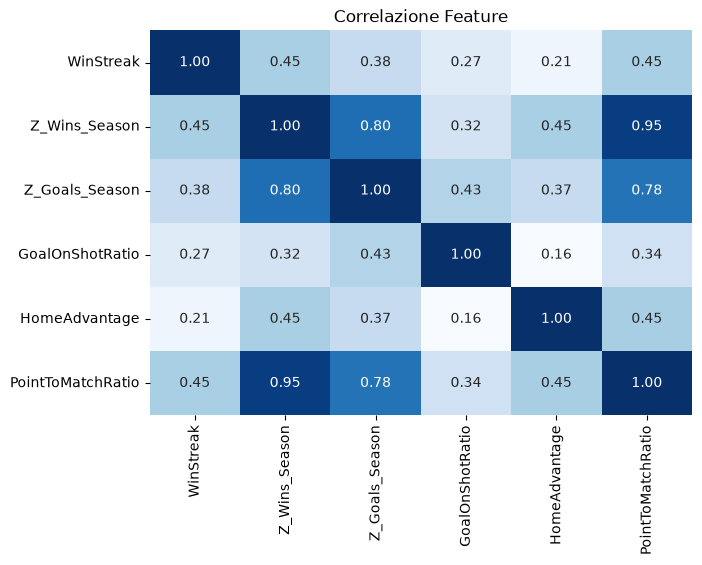

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap per le feature
plt.figure(figsize=(7, 5))

features = ["WinStreak", "Z_Wins_Season", "Z_Goals_Season", "GoalOnShotRatio", "HomeAdvantage", "PointToMatchRatio", "Elo"]
sns.heatmap(dataset[features].corr(), annot=True, cmap='Blues', fmt=".2f", cbar=False)

plt.title('Correlazione Feature')
plt.show()


Notiamo che nella tabella che le feature più ridondanti sono quelle colorate in blu scuro (ovvero dove il valore si avvicina all'1). Nel seguente notebook le sceglieremo in base alla non ridondanza tra di esse.